# Titanic Survival Prediction Modal

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

In [6]:
# importing the data
# load data
file_path = Path.cwd().parent / '.data/titanic.csv'
df = pd.read_csv(filepath_or_buffer=file_path)
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## Basic data cleaning

In [7]:
# creating a new col 'FamilySize' with 'SibSp' & 'Parch'
df['FamilySize'] = df['SibSp'] + df['Parch']

#dropping unnecessary columns
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], inplace=True)

df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0


In [8]:
print('SHAPE:', df.shape)
print('DUPLICATED ROWS:', df.duplicated().sum())

print('\nINFO:')
print(df.info())


SHAPE: (891, 7)
DUPLICATED ROWS: 112

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    str    
 3   Age         714 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    889 non-null    str    
 6   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 48.9 KB
None


In [9]:
# dropping duplicates
df.drop_duplicates(inplace=True, ignore_index=True)
print('SHAPE:', df.shape)

# We'll impute missing values in the pipeline

SHAPE: (779, 7)


# EDA (on raw data)

In [10]:
df.describe()

,Survived,Pclass,Age,Fare,FamilySize
count,779.000000,779.000000,676.000000,779.000000,779.000000
mean,0.412067,2.245186,29.812751,34.845116,0.942234
std,0.492523,0.854573,14.727098,52.295104,1.520384
min,0.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,8.050000,0.000000
50%,0.000000,3.000000,28.000000,15.900000,0.000000
75%,1.000000,3.000000,39.000000,34.375000,1.000000
max,1.000000,3.000000,80.000000,512.329200,10.000000


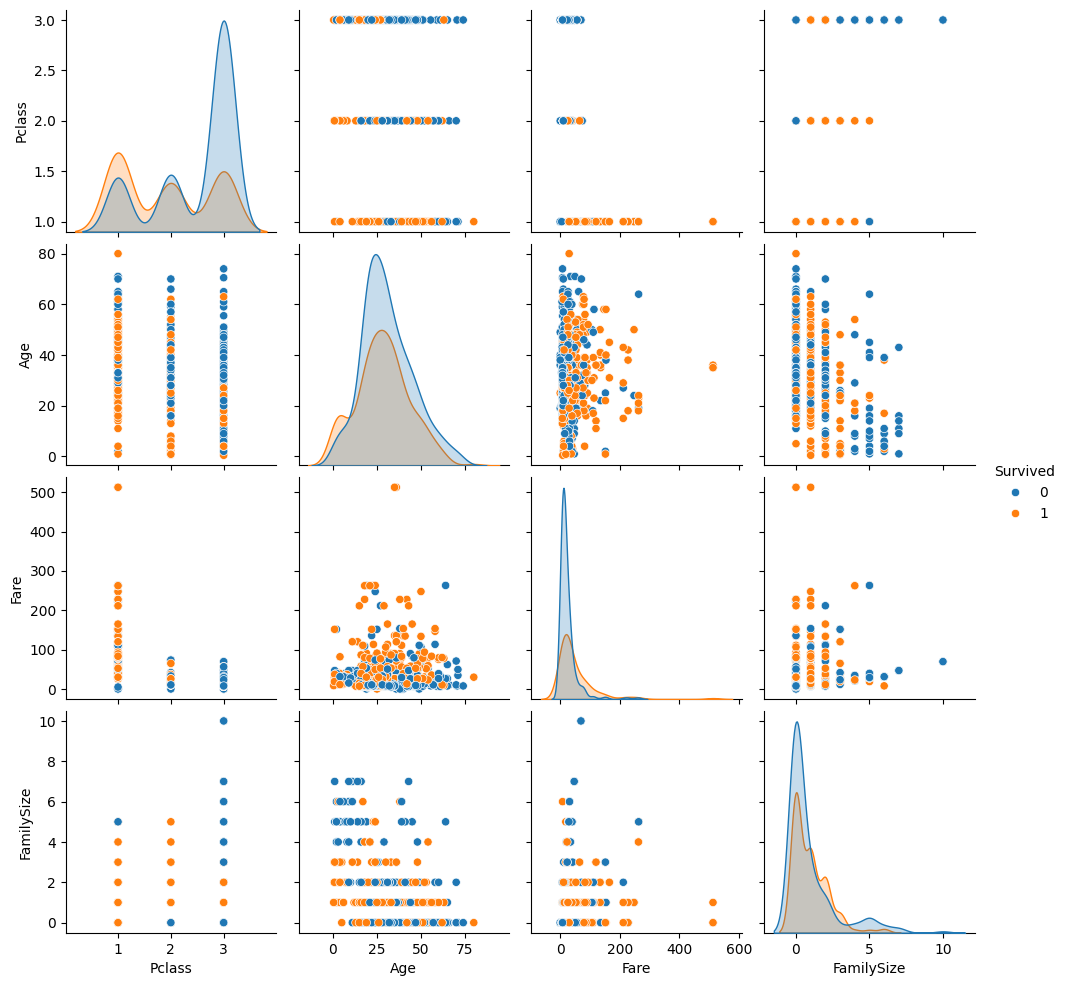

In [11]:
sns.pairplot(df, hue='Survived')

## Goals:

* Create a pipeline
    * Handle Missing Values
        * 'Age', 'Embarked' - `SimpleImputer`
    * Feature Engineering
        * 'Sex', 'Embarked' - `OneHotEncoder`
        * 'Fare' - `StandardScaler`
    * Model - `LogisticRegression`

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

### Splitting data

In [13]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Preprocessing

In [14]:
preprocessor = ColumnTransformer([
    ('age', SimpleImputer(strategy='mean'), ['Age']),
    # ('fare', StandardScaler(), ['Fare']),
    ('fare', FunctionTransformer(func=np.log1p), ['Fare']),
    ('sex', OneHotEncoder(drop='first'), ['Sex']),
    ('embarked', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first'))
    ]), ['Embarked'])
], remainder='passthrough')

### Model

In [15]:
model = LogisticRegression(max_iter=500)

## Pipeline:

In [16]:
pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])

# Result

In [17]:
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
score = pipe.score(X_test, y_test)

cv_score = cross_val_score(pipe, X, y, cv=5)
print('Score:   ', score)
print('CV Score:', cv_score.mean())

Score:    0.717948717948718
CV Score: 0.7676923076923077
